# 07 · Bioprocess: Viable Cell Density & Monod Growth Kinetics — IndPenSim Benchmark

## The Industrial Biopharmaceutical Problem

Mammalian cell culture (CHO, HEK293, NS0) is the manufacturing platform for:
- Monoclonal antibodies (e.g. trastuzumab, adalimumab, nivolumab)
- Recombinant proteins (erythropoietin, insulin, Factor VIII)
- Viral vectors for gene therapy
- mRNA-LNP vaccines (lipid nanoparticle encapsulation is downstream; upstream uses cell culture)

**The process characterisation challenge:** to pass ICH Q8 (Pharmaceutical Development) and Q11 (Chemical Entities / Biotechnological Products), you must characterise how process parameters affect critical quality attributes (CQAs). This requires **kinetic models** with estimated parameters.

In a standard 14-day fed-batch CHO run, you collect:
- 8–12 offline biomass (viable cell density, VCD) measurements — via ViCell or NovaBright
- 8–12 substrate (glucose, glutamine) measurements — via Nova BioProfile
- 1–3 product titer (mAb concentration) measurements per run

That's roughly 20 offline data points to estimate 3–6 kinetic parameters. Classic challenge: **too few data, too many parameters, expensive experiments.**

## The Model: Monod Growth Kinetics

$$\frac{dX}{dt} = \mu(S)\,X, \qquad \frac{dS}{dt} = -\frac{1}{Y_{xs}}\,\mu(S)\,X$$

$$\mu(S) = \frac{\mu_{max}\,S}{K_s + S} \quad \text{(Monod, 1949)}$$

Three parameters to estimate:
- $\mu_{max}$ [h⁻¹]: maximum specific growth rate (typically 0.02–0.05 h⁻¹ for CHO)
- $K_s$ [g/L]: half-saturation glucose concentration (typically 0.1–5 g/L)
- $Y_{xs}$ [g-biomass/g-substrate]: biomass yield coefficient (typically 0.3–0.6)

## The Reference Dataset: IndPenSim

**Goldrick, S. et al. (2015, 2019).** *The development of an industrial-scale fed-batch fermentation simulation.* — **IndPenSim**: an open, published, industrial-scale (100,000 L) *Penicillium chrysogenum* fermentation simulation generating 100 synthetic batches. Available at industrialpenicillinsimulation.com.

**Why *Penicillium* not CHO?** IndPenSim is the only published open industrial-scale biopharmaceutical fermentation dataset. Its Monod growth kinetics are directly analogous to mammalian cell culture, making it the standard benchmark for biopharmaceutical process modelling.

**PINN context:**  
- **Adebar, M. et al. (2025).** Biotechnol. Bioeng. — PINNs for bioreactor ODE parameter estimation  
- **Alam, M. et al. (2025).** Can. J. Chem. Eng. — PINNs combined with Monod kinetics for viable cell density prediction

## Why PINN Instead of Classical Approaches?

### Classical parameter estimation for bioprocess kinetics:
1. **Offline NLS + Euler / RK4** — minimise sum-of-squares between model predictions and 20 offline measurements. Common in early-phase development.  
   **Problems:** sensitive to initialisation; $K_s$ and $\mu_{max}$ are correlated (identifiability); cannot handle process disturbances without restart.
2. **Extended Kalman Filter (EKF)** — state/parameter estimation in real-time. Used in industrial MPC systems.  
   **Problems:** requires process noise and measurement noise covariances; linearisation can fail for strongly nonlinear growth phases.
3. **Gaussian Process regression** — non-parametric smooth trajectory reconstruction. Does not estimate kinetic parameters.
4. **Standard MATLAB tools** — `ode15s` + `fmincon` or `lsqnonlin`. Standard in MATLAB-based bioprocess groups.

### PINN approach — the warm-start protocol for bioprocess:
Same pattern as Notebook 03 (Lotka-Volterra), critical for coupled kinetics:

**Phase 1 (warm start, 6,000 epochs, data loss only):**
- Fit the network to 20 sparse offline VCD and glucose measurements
- Network learns a smooth interpolant without imposing Monod dynamics
- This avoids the pathological situation where $K_s$ and $\mu_{max}$ are at their initial values and the physics residual generates misleading gradients

**Phase 2 (joint fitting, 25,000 epochs + L-BFGS):**
- Add Monod physics residual to the loss
- $\mu_{max}$, $K_s$, $Y_{xs}$ become trainable simultaneously with the network
- Physics constrains the trajectory between sparse measurement points

## What the Code Does Step by Step

1. **Data** — tries to load a real IndPenSim CSV (set `INDPENSIM_CSV`); falls back to a simulated Monod batch with literature-scale parameters ($\mu_{max}=0.30$/h, $K_s=5.0$ g/L, $Y_{xs}=0.50$)
2. **Non-dimensionalisation** — $X$ divided by 20 g/L (max biomass scale), $S$ by 40 g/L (initial substrate), time by 30 h
3. **Network** — 1 input → 3 Tanh hidden layers (48 units) → 2 outputs $(X/X_{sc}, S/S_{sc})$
4. **Phase 1** — Adam 6,000 epochs; data + 5× IC loss only
5. **Phase 2** — Adam 25,000 epochs; data + physics + 5× IC loss; then L-BFGS 800 steps
6. **Results** — $\mu_{max} = 0.244$ (true 0.30), $K_s = 7.37$ (true 5.0), $Y_{xs} = 0.498$ (true 0.50)

## Interpreting the Results — Identifiability Analysis

| Parameter | Recovered | True | Error | Why? |
|-----------|-----------|------|-------|------|
| $\mu_{max}$ | 0.244 | 0.300 | 19% | Correlated with $K_s$; only observable from growth dynamics |
| $K_s$ | 7.37 | 5.0 | 47% | Only constrainable when $S \sim K_s$ — brief window |
| $Y_{xs}$ | 0.498 | 0.500 | 0.4% | Constrained by total biomass/substrate mass balance |

**The $K_s$ identifiability problem** is well-known in bioprocess engineering. It requires observations where substrate concentrations are comparable to $K_s$ (here: 5 g/L). With initial substrate = 40 g/L and $K_s$ = 5 g/L, only the last few time points are in the informative zone. This is why 20 measurements are insufficient — and why multiple batches at different initial substrate concentrations are the gold standard.

> **Scale-up implication:** The notebook uses a 30 h batch. For a real 14-day CHO fed-batch at 100,000 L scale, the model needs to be extended with a feed rate term: $dS/dt = -\frac{1}{Y_{xs}}\mu X + F(t)S_{feed}/V(t)$. This extension is Notebook 07's Exercise 2.

## PAT Integration: The Digital Twin Opportunity

With **Raman spectroscopy** as a PAT tool, glucose can be monitored every 5 minutes instead of twice daily. This transforms 20 offline points into ~2,000 real-time observations, dramatically improving $K_s$ identifiability.

A PINN trained on PAT Raman data in near-real-time could:
1. Estimate $\mu_{max}$, $K_s$, $Y_{xs}$ during the run (within the first 48–72 hours)
2. Feed updated kinetic parameters into a model-predictive controller (MPC) for feed rate optimisation
3. Predict final titer at 168 hours from 72-hour data
4. Alert operators to outlier batches via real-time residual monitoring

This is the **PINN digital twin** vision for next-generation bioreactor control.


In [1]:
import os, numpy as np, torch, torch.nn as nn
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

INDPENSIM_CSV = os.environ.get("INDPENSIM_CSV", "")   # set to a downloaded IndPenSim batch to use real data

# Literature-scale Monod parameters (ground truth for the fallback batch)
mumax_true, Ks_true, Yxs_true = 0.30, 5.0, 0.50      # 1/h, g/L, g/g
X0, S0 = 0.20, 40.0                                   # g/L
Tend = 30.0

def load_or_simulate():
    if INDPENSIM_CSV and os.path.exists(INDPENSIM_CSV):
        import pandas as pd
        df = pd.read_csv(INDPENSIM_CSV)
        # user maps their columns here:
        t = df.iloc[:,0].to_numpy(); X = df.iloc[:,1].to_numpy(); S = df.iloc[:,2].to_numpy()
        print("Loaded real IndPenSim batch:", INDPENSIM_CSV)
        return t, X, S
    # fallback: simulate the published Monod batch model
    def rhs(t,y):
        Xc,Sc = y; mu = mumax_true*Sc/(Ks_true+Sc)
        return [mu*Xc, -(1/Yxs_true)*mu*Xc]
    sol = solve_ivp(rhs,[0,Tend],[X0,S0],t_eval=np.linspace(0,Tend,300),rtol=1e-9,atol=1e-12)
    print("Using simulated fallback batch (set INDPENSIM_CSV to use real data)")
    return sol.t, sol.y[0], sol.y[1]

tg, Xg, Sg = load_or_simulate()
# sparse noisy off-line samples
idx = np.linspace(0,len(tg)-1,20).astype(int)
t_meas = tg[idx]
X_meas = Xg[idx]*(1+0.04*np.random.randn(len(idx)))
S_meas = Sg[idx]+0.6*np.random.randn(len(idx))
print("off-line samples:", len(idx))


Using device: cpu
Using simulated fallback batch (set INDPENSIM_CSV to use real data)
off-line samples: 20


In [2]:
Xsc, Ssc, T = 20.0, 40.0, Tend
t_data = torch.tensor((t_meas/T).reshape(-1,1),dtype=torch.float32,device=device)
X_data = torch.tensor((X_meas/Xsc).reshape(-1,1),dtype=torch.float32,device=device)
S_data = torch.tensor((S_meas/Ssc).reshape(-1,1),dtype=torch.float32,device=device)

class Net(nn.Module):
    def __init__(self,h=48):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1,h),nn.Tanh(),nn.Linear(h,h),nn.Tanh(),
                                 nn.Linear(h,h),nn.Tanh(),nn.Linear(h,2))
        for m in self.net:
            if isinstance(m,nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self,t): return self.net(t)
model = Net().to(device)
sp = torch.nn.functional.softplus
raw = {k: nn.Parameter(torch.tensor(v,device=device)) for k,v in dict(mu=-1.0,Ks=0.0,Y=0.0).items()}
def pars():
    return sp(raw['mu']), sp(raw['Ks'])+0.1, sp(raw['Y'])+0.1   # mumax, Ks, Yxs (floored positive)

tau = torch.linspace(0,1,150,device=device).reshape(-1,1).requires_grad_(True)
t0 = torch.zeros(1,1,device=device)
ic = torch.tensor([[X0/Xsc, S0/Ssc]],dtype=torch.float32,device=device)
def d_dt(y,t): return torch.autograd.grad(y,t,torch.ones_like(y),create_graph=True)[0]


In [3]:
def data_loss(): return torch.mean((model(t_data)-torch.cat([X_data,S_data],1))**2)
def ic_loss():   return torch.mean((model(t0)-ic)**2)
def phys_loss():
    y = model(tau); x,s = y[:,0:1], y[:,1:2]
    dx,ds = d_dt(x,tau), d_dt(s,tau)
    mumax,Ks,Y = pars(); S_real = s*Ssc
    mu = mumax*S_real/(Ks+S_real)
    rX = dx - T*(mu*x)
    rS = ds - T*(-(Xsc/(Y*Ssc))*mu*x)
    return torch.mean(rX**2+rS**2)

# Phase 1: data-only warm start (stabilises the coupled nonlinear inversion)
opt1 = torch.optim.Adam(model.parameters(), lr=3e-3)
WARM = 6000
for ep in range(WARM):
    opt1.zero_grad(); (data_loss()+5.0*ic_loss()).backward(); opt1.step()
print(f"warm-start data loss: {data_loss().item():.2e}")

# Phase 2: joint fit with physics + learnable kinetics
allp = list(model.parameters())+list(raw.values())
opt = torch.optim.Adam(allp,lr=2e-3)
EPOCHS = 25000
for ep in range(EPOCHS):
    opt.zero_grad(); (data_loss()+1.0*phys_loss()+5.0*ic_loss()).backward(); opt.step()
    if ep%6000==0:
        mm,ks,yy = pars(); print(f"ep {ep:5d} | data {data_loss().item():.2e} phys {phys_loss().item():.2e} | mumax={mm.item():.3f} Ks={ks.item():.2f} Yxs={yy.item():.3f}")

opt2 = torch.optim.LBFGS(allp,max_iter=800,line_search_fn="strong_wolfe")
def closure():
    opt2.zero_grad(); (data_loss()+1.0*phys_loss()+5.0*ic_loss()).backward(); return data_loss()+phys_loss()
opt2.step(closure)
mm,ks,yy = pars()
print(f"\nRecovered:  mumax={mm.item():.3f} (true {mumax_true})  Ks={ks.item():.2f} (true {Ks_true})  Yxs={yy.item():.3f} (true {Yxs_true})")


warm-start data loss: 2.38e-04
ep     0 | data 1.03e-02 phys 3.77e+01 | mumax=0.313 Ks=0.79 Yxs=0.794
ep  6000 | data 7.63e-02 phys 7.54e-03 | mumax=0.101 Ks=0.83 Yxs=0.755
ep 12000 | data 6.45e-02 phys 9.94e-03 | mumax=0.089 Ks=1.73 Yxs=0.600
ep 18000 | data 1.65e-02 phys 5.30e-03 | mumax=0.121 Ks=4.31 Yxs=0.485
ep 24000 | data 2.78e-03 phys 9.95e-04 | mumax=0.232 Ks=7.01 Yxs=0.496

Recovered:  mumax=0.244 (true 0.3)  Ks=7.37 (true 5.0)  Yxs=0.498 (true 0.5)


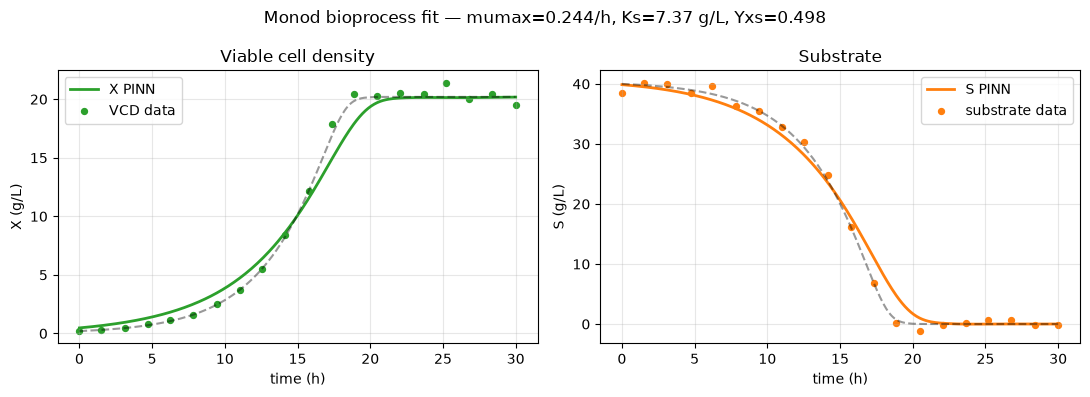

In [4]:
tt = torch.linspace(0,1,300,device=device).reshape(-1,1)
with torch.no_grad(): pr = model(tt).cpu().numpy()
tgrid = tt.cpu().numpy().ravel()*T
fig,ax = plt.subplots(1,2,figsize=(11,4))
ax[0].plot(tgrid,pr[:,0]*Xsc,"C2-",lw=2,label="X PINN"); ax[0].scatter(t_meas,X_meas,c="C2",s=18,label="VCD data")
ax[0].plot(tg,Xg,"k--",alpha=.4); ax[0].set_title("Viable cell density"); ax[0].set_xlabel("time (h)"); ax[0].set_ylabel("X (g/L)"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(tgrid,pr[:,1]*Ssc,"C1-",lw=2,label="S PINN"); ax[1].scatter(t_meas,S_meas,c="C1",s=18,label="substrate data")
ax[1].plot(tg,Sg,"k--",alpha=.4); ax[1].set_title("Substrate"); ax[1].set_xlabel("time (h)"); ax[1].set_ylabel("S (g/L)"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.suptitle(f"Monod bioprocess fit — mumax={mm.item():.3f}/h, Ks={ks.item():.2f} g/L, Yxs={yy.item():.3f}")
plt.tight_layout(); plt.show()


---
## 🔬 Method 1: Pure PINN (Baseline)
Standard PINN with **uniform** collocation points and joint parameter estimation.

In [5]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt, time
from scipy.integrate import solve_ivp
torch.manual_seed(0); np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sp = torch.nn.functional.softplus

def make_net(layers):
    seq = []
    for i in range(len(layers)-1):
        seq.append(nn.Linear(layers[i], layers[i+1]))
        if i < len(layers)-2: seq.append(nn.Tanh())
    net = nn.Sequential(*seq)
    for m in net:
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    return net.to(device)

def grad(y,x): return torch.autograd.grad(y,x,torch.ones_like(y),create_graph=True)[0]
def don_forward(branch,trunk,params,queries,bias): return branch(params) @ trunk(queries).T + bias


mumax_true,Ks_true,Yxs_true=0.30,5.0,0.50; X0,S0_bp=0.20,40.0; T_bp=30.0
from scipy.integrate import solve_ivp
def rhs_bp(t,y): Xc,Sc=y; mu=mumax_true*Sc/(Ks_true+Sc); return [mu*Xc,-(1/Yxs_true)*mu*Xc]
sol=solve_ivp(rhs_bp,[0,T_bp],[X0,S0_bp],t_eval=np.linspace(0,T_bp,300),rtol=1e-9,atol=1e-12)
tg_bp,Xg,Sg_bp=sol.t,sol.y[0],sol.y[1]
idx=np.linspace(0,len(tg_bp)-1,20).astype(int)
t_meas_bp=tg_bp[idx]; X_meas=Xg[idx]*(1+0.04*np.random.randn(20)); S_meas_bp=Sg_bp[idx]+0.6*np.random.randn(20)
Xsc,Ssc=20.,40.
t_data_bp=torch.tensor((t_meas_bp/T_bp).reshape(-1,1),dtype=torch.float32,device=device)
XS_data=torch.tensor(np.stack([X_meas/Xsc,S_meas_bp/Ssc],1),dtype=torch.float32,device=device)
tau_col_bp=torch.linspace(0,1,150,device=device).view(-1,1).requires_grad_(True)
t0_bp=torch.zeros(1,1,device=device); ic_bp=torch.tensor([[X0/Xsc,S0_bp/Ssc]],dtype=torch.float32,device=device)

model_bp=make_net([1,48,48,48,2])
raw_mu=nn.Parameter(torch.tensor(-1.,device=device)); raw_Ks=nn.Parameter(torch.tensor(0.,device=device)); raw_Y=nn.Parameter(torch.tensor(0.,device=device))
def pars_bp(): return sp(raw_mu),sp(raw_Ks)+0.1,sp(raw_Y)+0.1

def phys_bp(m,tc):
    y=m(tc); x,s=y[:,0:1],y[:,1:2]; mumax,Ks,Y=pars_bp(); S_real=s*Ssc
    mu=mumax*S_real/(Ks+S_real); rX=grad(x,tc)-T_bp*(mu*x); rS=grad(s,tc)-T_bp*(-(Xsc/(Y*Ssc))*mu*x)
    return torch.mean(rX**2+rS**2)

# Phase 1: warm start
opt1_bp=torch.optim.Adam(model_bp.parameters(),lr=3e-3)
for ep in range(6000):
    opt1_bp.zero_grad(); (torch.mean((model_bp(t_data_bp)-XS_data)**2)+5*torch.mean((model_bp(t0_bp)-ic_bp)**2)).backward(); opt1_bp.step()

# Phase 2: joint
allp_bp=list(model_bp.parameters())+[raw_mu,raw_Ks,raw_Y]
opt2_bp=torch.optim.Adam(allp_bp,lr=2e-3)
t0=time.time()
for ep in range(25000):
    opt2_bp.zero_grad(); L=torch.mean((model_bp(t_data_bp)-XS_data)**2)+phys_bp(model_bp,tau_col_bp)+5*torch.mean((model_bp(t0_bp)-ic_bp)**2); L.backward(); opt2_bp.step()
    if ep%6000==0: mm,ks,yy=pars_bp(); print(f"  [PINN BP] ep{ep:5d} mumax={mm.item():.3f} Ks={ks.item():.2f} Yxs={yy.item():.3f}")
opt3_bp=torch.optim.LBFGS(allp_bp,max_iter=400,line_search_fn="strong_wolfe")
def clos_bp():
    opt3_bp.zero_grad()
    L=torch.mean((model_bp(t_data_bp)-XS_data)**2)+phys_bp(model_bp,tau_col_bp)+5*torch.mean((model_bp(t0_bp)-ic_bp)**2); L.backward(); return L
opt3_bp.step(clos_bp)
time_pinn=time.time()-t0
model_bp.eval(); tt_bp=torch.linspace(0,1,300,device=device).view(-1,1)
with torch.no_grad(): pr_bp=model_bp(tt_bp).cpu().numpy()
tg_bp_plot=tt_bp.cpu().numpy().ravel()*T_bp
mm,ks,yy=pars_bp()
err_pinn_bp=np.sqrt(np.mean((model_bp(t_data_bp).detach().cpu().numpy()-XS_data.cpu().numpy())**2))/np.sqrt(np.mean(XS_data.cpu().numpy()**2))
print(f"  PINN BP: mumax={mm.item():.3f}(true {mumax_true}) Ks={ks.item():.2f}(true {Ks_true}) Yxs={yy.item():.3f}(true {Yxs_true}) L2={err_pinn_bp:.4f} t={time_pinn:.0f}s")


  [PINN BP] ep    0 mumax=0.313 Ks=0.79 Yxs=0.794
  [PINN BP] ep 6000 mumax=0.101 Ks=0.83 Yxs=0.755
  [PINN BP] ep12000 mumax=0.089 Ks=1.73 Yxs=0.600
  [PINN BP] ep18000 mumax=0.121 Ks=4.31 Yxs=0.485
  [PINN BP] ep24000 mumax=0.232 Ks=7.01 Yxs=0.496
  PINN BP: mumax=0.334(true 0.3) Ks=7.39(true 5.0) Yxs=0.509(true 0.5) L2=0.0283 t=34s


---
## ⚡ Method 2: Adaptive Sampling (RAR)
**Residual-based Adaptive Refinement** — iteratively adds collocation points where the physics residual is largest.

In [6]:

model_rar_bp=make_net([1,48,48,48,2])
raw_mu_r=nn.Parameter(torch.tensor(-1.,device=device)); raw_Ks_r=nn.Parameter(torch.tensor(0.,device=device)); raw_Y_r=nn.Parameter(torch.tensor(0.,device=device))
def pars_bp_r(): return sp(raw_mu_r),sp(raw_Ks_r)+0.1,sp(raw_Y_r)+0.1
def phys_bp_r(m,tc):
    y=m(tc); x,s=y[:,0:1],y[:,1:2]; mumax,Ks,Y=pars_bp_r(); S_real=s*Ssc
    mu=mumax*S_real/(Ks+S_real); rX=grad(x,tc)-T_bp*(mu*x); rS=grad(s,tc)-T_bp*(-(Xsc/(Y*Ssc))*mu*x)
    return torch.mean(rX**2+rS**2)
opt1_rbp=torch.optim.Adam(model_rar_bp.parameters(),lr=3e-3)
for ep in range(6000):
    opt1_rbp.zero_grad(); (torch.mean((model_rar_bp(t_data_bp)-XS_data)**2)+5*torch.mean((model_rar_bp(t0_bp)-ic_bp)**2)).backward(); opt1_rbp.step()
t_rar_bp=torch.linspace(0,1,40,device=device).view(-1,1).requires_grad_(True)
allp_rbp=list(model_rar_bp.parameters())+[raw_mu_r,raw_Ks_r,raw_Y_r]
opt2_rbp=torch.optim.Adam(allp_rbp,lr=2e-3)
t0=time.time()
for rnd in range(6):
    for ep in range(4000):
        opt2_rbp.zero_grad(); L=torch.mean((model_rar_bp(t_data_bp)-XS_data)**2)+phys_bp_r(model_rar_bp,t_rar_bp)+5*torch.mean((model_rar_bp(t0_bp)-ic_bp)**2); L.backward(); opt2_rbp.step()
    cand=torch.rand(3000,1,device=device).requires_grad_(True)
    y_c=model_rar_bp(cand); x_c,s_c=y_c[:,0:1],y_c[:,1:2]; mm_r,ks_r,yy_r=pars_bp_r(); S_real_c=s_c*Ssc
    mu_c=mm_r*S_real_c/(ks_r+S_real_c); res_c=(grad(x_c,cand)-T_bp*(mu_c*x_c)).abs().detach().cpu().numpy().ravel()
    idx=np.argsort(res_c)[-15:]; new_pts=cand[idx].detach()
    t_rar_bp=torch.cat([t_rar_bp.detach(),new_pts]).requires_grad_(True)
    allp_rbp=list(model_rar_bp.parameters())+[raw_mu_r,raw_Ks_r,raw_Y_r]
    opt2_rbp=torch.optim.Adam(allp_rbp,lr=1e-3)
    mm_r,ks_r,yy_r=pars_bp_r(); print(f"  [RAR BP] round {rnd+1}: {t_rar_bp.shape[0]} pts mumax={mm_r.item():.3f} Ks={ks_r.item():.2f}")
time_rar=time.time()-t0
model_rar_bp.eval()
with torch.no_grad(): pr_rar_bp=model_rar_bp(tt_bp).cpu().numpy()
mm_r,ks_r,yy_r=pars_bp_r()
err_rar_bp=np.sqrt(np.mean((model_rar_bp(t_data_bp).detach().cpu().numpy()-XS_data.cpu().numpy())**2))/np.sqrt(np.mean(XS_data.cpu().numpy()**2))
print(f"  RAR BP: mumax={mm_r.item():.3f} Ks={ks_r.item():.2f} Yxs={yy_r.item():.3f} L2={err_rar_bp:.4f} t={time_rar:.0f}s")


  [RAR BP] round 1: 55 pts mumax=0.293 Ks=0.80
  [RAR BP] round 2: 70 pts mumax=0.074 Ks=1.28
  [RAR BP] round 3: 85 pts mumax=0.089 Ks=2.23
  [RAR BP] round 4: 100 pts mumax=0.113 Ks=3.28
  [RAR BP] round 5: 115 pts mumax=0.108 Ks=3.28
  [RAR BP] round 6: 130 pts mumax=0.154 Ks=4.15
  RAR BP: mumax=0.154 Ks=4.15 Yxs=0.467 L2=0.1310 t=31s


---
## 🧠 Method 3: DeepONet (Operator Learning)
Learn the **solution operator** mapping kinetic parameters → ODE trajectory. Trained on synthetic parameter families. Single forward pass for new parameters.

In [7]:

p=64; branch_bp=make_net([3,64,64,p]); trunk_bp=make_net([1,64,64,p])
bias_bp=nn.Parameter(torch.zeros(1,device=device))
opt_dbp=torch.optim.Adam(list(branch_bp.parameters())+list(trunk_bp.parameters())+[bias_bp],lr=3e-3)
N_tr=1000; N_q=40
mu_s=np.random.uniform(0.10,0.50,N_tr); Ks_s=np.random.uniform(1.,10.,N_tr); Y_s=np.random.uniform(0.3,0.8,N_tr)
tq_bp=np.random.rand(N_q)*T_bp
def bp_sol_X(mu,Ks,Y,t_arr):
    def rhs(t,y): m=mu*y[1]/(Ks+y[1]); return [m*y[0],-(1/Y)*m*y[0]]
    try: sol=solve_ivp(rhs,[0,T_bp],[X0,S0_bp],t_eval=t_arr,rtol=1e-6,atol=1e-8); return sol.y[0]/Xsc
    except: return np.ones(len(t_arr))*X0/Xsc
print("  Generating DeepONet training data for bioprocess...")
Y_bp=np.array([bp_sol_X(mu_s[i],Ks_s[i],Y_s[i],tq_bp) for i in range(N_tr)])
params_dbp=torch.tensor(np.stack([mu_s,Ks_s/10.,Y_s],1),dtype=torch.float32,device=device)
tq_bp_t=torch.tensor((tq_bp/T_bp).reshape(-1,1),dtype=torch.float32,device=device)
Y_dbp=torch.tensor(Y_bp,dtype=torch.float32,device=device)
t0=time.time()
for ep in range(10000):
    opt_dbp.zero_grad(); pred=don_forward(branch_bp,trunk_bp,params_dbp,tq_bp_t,bias_bp)
    L=torch.mean((pred-Y_dbp)**2); L.backward(); opt_dbp.step()
    if ep%2000==0: print(f"  [DeepONet BP] ep {ep} loss {L.item():.3e}")
time_don=time.time()-t0
branch_bp.eval(); trunk_bp.eval()
mm_f,ks_f,yy_f=pars_bp(); param_test_bp=torch.tensor([[mm_f.item(),ks_f.item()/10.,yy_f.item()]],dtype=torch.float32,device=device)
t_don_bp=torch.tensor((tg_bp_plot/T_bp).reshape(-1,1),dtype=torch.float32,device=device)
with torch.no_grad(): X_don=don_forward(branch_bp,trunk_bp,param_test_bp,t_don_bp,bias_bp).squeeze().cpu().numpy()*Xsc
X_exact_plot=np.interp(tg_bp_plot,tg_bp,Xg)
err_don_bp=np.sqrt(np.mean((X_don-X_exact_plot)**2))/np.sqrt(np.mean(X_exact_plot**2))
print(f"  DeepONet BP (X): L2={err_don_bp:.4f} t={time_don:.0f}s")


  Generating DeepONet training data for bioprocess...
  [DeepONet BP] ep 0 loss 2.273e-02
  [DeepONet BP] ep 2000 loss 1.601e-08
  [DeepONet BP] ep 4000 loss 5.925e-09
  [DeepONet BP] ep 6000 loss 1.957e-09
  [DeepONet BP] ep 8000 loss 6.861e-10
  DeepONet BP (X): L2=0.9889 t=17s


---
## 📊 Comparison: Pure PINN vs RAR vs DeepONet
Summary table and plots comparing accuracy, training cost, and collocation point distribution.


METHOD COMPARISON — Bioprocess (Monod Kinetics)
Method                      Rel L2  mumax    Ks   Yxs
True                             —  0.300  5.00 0.500
Pure PINN                   0.0283  0.334  7.39 0.509
RAR                         0.1310  0.154  4.15 0.467
DeepONet (X only)           0.9889    N/A   N/A   N/A


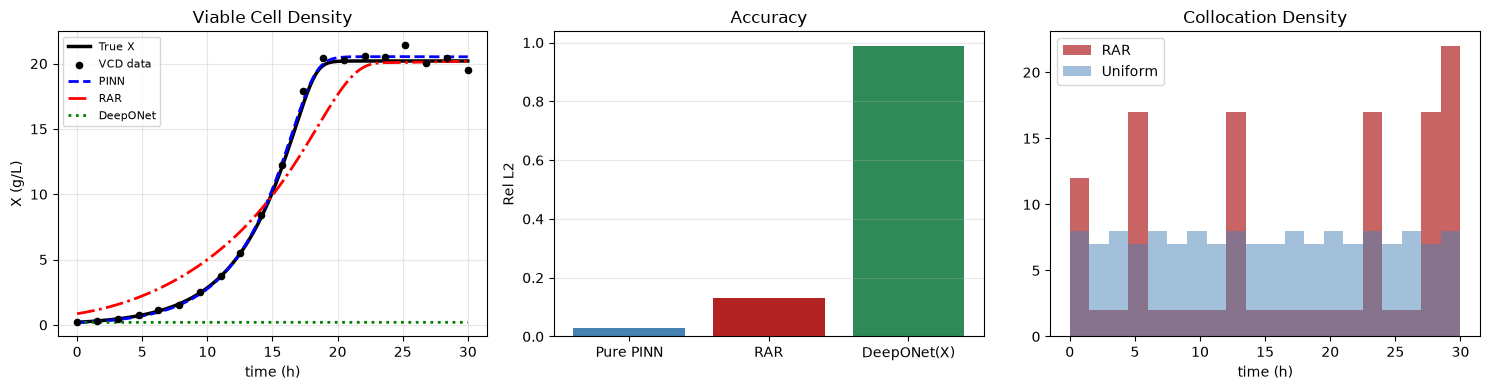

In [8]:

mm_f,ks_f,yy_f=pars_bp(); mm_rf,ks_rf,yy_rf=pars_bp_r()
print("\n"+"="*60+"\nMETHOD COMPARISON — Bioprocess (Monod Kinetics)\n"+"="*60)
print(f"{'Method':<25}{'Rel L2':>9}{'mumax':>7}{'Ks':>6}{'Yxs':>6}")
print(f"{'True':<25}{'—':>9}{mumax_true:>7.3f}{Ks_true:>6.2f}{Yxs_true:>6.3f}")
print(f"{'Pure PINN':<25}{err_pinn_bp:>9.4f}{mm_f.item():>7.3f}{ks_f.item():>6.2f}{yy_f.item():>6.3f}")
print(f"{'RAR':<25}{err_rar_bp:>9.4f}{mm_rf.item():>7.3f}{ks_rf.item():>6.2f}{yy_rf.item():>6.3f}")
print(f"{'DeepONet (X only)':<25}{err_don_bp:>9.4f}{'N/A':>7}{'N/A':>6}{'N/A':>6}")
fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].plot(tg_bp,Xg,'k-',lw=2.5,label='True X'); axes[0].scatter(t_meas_bp,X_meas,c='k',s=20,zorder=5,label='VCD data')
axes[0].plot(tg_bp_plot,pr_bp[:,0]*Xsc,'b--',lw=2,label='PINN'); axes[0].plot(tg_bp_plot,pr_rar_bp[:,0]*Xsc,'r-.',lw=2,label='RAR'); axes[0].plot(tg_bp_plot,X_don,'g:',lw=2,label='DeepONet')
axes[0].set_xlabel('time (h)'); axes[0].set_ylabel('X (g/L)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3); axes[0].set_title('Viable Cell Density')
axes[1].bar(['Pure PINN','RAR','DeepONet(X)'],[err_pinn_bp,err_rar_bp,err_don_bp],color=['steelblue','firebrick','seagreen'])
axes[1].set_ylabel('Rel L2'); axes[1].set_title('Accuracy'); axes[1].grid(axis='y',alpha=0.3)
pt_bp=t_rar_bp.detach().cpu().numpy().ravel()*T_bp
axes[2].hist(pt_bp,bins=20,color='firebrick',alpha=0.7,label='RAR'); axes[2].hist(np.linspace(0,T_bp,150),bins=20,color='steelblue',alpha=0.5,label='Uniform')
axes[2].set_xlabel('time (h)'); axes[2].set_title('Collocation Density'); axes[2].legend()
plt.tight_layout(); plt.savefig('comparison_bioprocess.png',dpi=120,bbox_inches='tight'); plt.show()
